<a href="https://colab.research.google.com/github/SenTier1107/DataManagement_2026/blob/main/Text_Classification_CountVectorizer_2026/NLP%EA%B8%B0%EC%B4%88%3A%20CountVectorizer%26%EC%BD%94%EC%82%AC%EC%9D%B8%EC%9C%A0%EC%82%AC%EB%8F%84_%EA%B8%B0%EB%B0%98_%ED%85%8D%EC%8A%A4%ED%8A%B8%EB%B6%84%EB%A5%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [과제] NLP 기초: CountVectorizer를 이용한 뉴스 그룹 대화 분류 (코사인 유사도)

---

## 1. 과제 개요

본 과제에서는 `sklearn` 라이브러리의 **20 Newsgroups 데이터셋**을 활용하여 텍스트 데이터를 수치화하고,  
**코사인 유사도(Cosine Similarity)** 를 통해 새로운 문장이 어떤 주제에 속하는지 분류하는 프로그램을 작성한다.

### 처리 흐름

```
① 뉴스 데이터 수집 (fetch_20newsgroups)
        ↓
② 텍스트 전처리 (헤더/푸터/인용구 제거)
        ↓
③ CountVectorizer로 단어 빈도 벡터화
        ↓
④ 코사인 유사도 계산 → 카테고리 분류
        ↓
⑤ Gradio 웹 서비스로 배포
```

### 사용 카테고리
| 카테고리 | 주제 |
|---|---|
| `comp.graphics` | 컴퓨터 그래픽 |
| `sci.space` | 우주 과학 |
| `talk.religion.misc` | 종교 토론 |

---
## 2. 라이브러리 임포트

- `fetch_20newsgroups`: sklearn에 내장된 뉴스그룹 데이터셋 로더
- `CountVectorizer`: 텍스트를 단어 빈도 기반의 숫자 벡터로 변환
- `cosine_similarity`: 두 벡터 간의 코사인 유사도 계산
- `numpy`: 배열 처리 및 인덱스 탐색

In [1]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print("라이브러리 임포트 완료")

라이브러리 임포트 완료


---
## 3. Step 1 - 데이터 로드 및 샘플링

### 데이터 전처리 옵션: `remove=('headers', 'footers', 'quotes')`
- **headers**: 발신자 이메일, 날짜, 뉴스그룹 이름 등 메타 정보 제거
- **footers**: 서명(signature) 등 본문 하단 불필요 정보 제거
- **quotes**: `>` 로 시작하는 인용 답변 제거

이 옵션을 적용해야 모델이 **순수 본문 내용**만 학습하게 된다.

### 샘플 수: 각 카테고리당 20개
의도적으로 적은 샘플을 사용하여, 데이터 부족 시 발생하는 **유사도 0 현상**을 직접 경험한다.

In [2]:
# 3가지 카테고리 지정
categories = ['comp.graphics', 'sci.space', 'talk.religion.misc']

# 데이터 로드 (헤더/푸터/인용구 제거)
newsgroups = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes')
)

# 각 카테고리별 20개씩 샘플링
data, labels = [], []
SAMPLE_SIZE = 20

for i, category in enumerate(categories):
    indices = np.where(newsgroups.target == i)[0][:SAMPLE_SIZE]
    for idx in indices:
        data.append(newsgroups.data[idx])
        labels.append(newsgroups.target_names[i])

print(f"총 로드된 문서 수: {len(data)}")
print(f"카테고리별 분포: {SAMPLE_SIZE}개 × {len(categories)}개 = {len(data)}개")
print(f"\n[샘플 미리보기 - comp.graphics 첫 번째 문서]")
print(data[0][:300], "...")

총 로드된 문서 수: 60
카테고리별 분포: 20개 × 3개 = 60개

[샘플 미리보기 - comp.graphics 첫 번째 문서]
Does anyone know the phone number to a place where i can get
a VGA passthrough?

	I want to hook up my VGA card to my XGA card (whcih you can can).
All I need is the cable that connects them.  It is the same type of
cable that you would connect from your VGA card to say a Video Blaster
or something. ...


---
## 4. Step 2 - CountVectorizer를 이용한 텍스트 벡터화

### CountVectorizer 동작 원리

```
문서1: "the rocket launched into space"
문서2: "space rocket orbit launch"

어휘사전: {launch:0, launched:1, orbit:2, rocket:3, space:4}
                                          (the, into → 불용어 제거)

문서1 벡터: [0, 1, 0, 1, 1]
문서2 벡터: [1, 0, 1, 1, 1]
```

- `stop_words='english'`: "a", "the", "is" 등 의미 없는 관용어 자동 제거
- `fit_transform()`: 어휘 사전 학습(fit) + 행렬 변환(transform) 동시 수행
- 결과는 **희소 행렬(Sparse Matrix)** 형태로 저장 (0이 많아 메모리 효율적)

In [3]:
# CountVectorizer 선언 및 학습
vectorizer = CountVectorizer(stop_words='english')
count_matrix = vectorizer.fit_transform(data)

# 결과 확인
vocab = vectorizer.get_feature_names_out()
print(f"생성된 어휘 사전 크기: {len(vocab)}개 단어")
print(f"행렬 크기: {count_matrix.shape}  → (문서 수, 어휘 수)")
print(f"\n어휘 사전 샘플 (처음 20개): {vocab[:20]}")

생성된 어휘 사전 크기: 2342개 단어
행렬 크기: (60, 2342)  → (문서 수, 어휘 수)

어휘 사전 샘플 (처음 20개): ['000' '02' '0865' '10' '100' '10bps' '11' '111' '12' '13' '130' '131'
 '14' '142' '15' '150' '1500' '152' '15rpm' '16']


---
## 5. Step 3 - 코사인 유사도 기반 분류 함수 구현

### 코사인 유사도(Cosine Similarity)란?

두 벡터 사이의 **각도**를 이용해 유사성을 측정한다.

$$sim(A, B) = \cos(\theta) = \frac{A \cdot B}{\|A\| \|B\|}$$

| 유사도 값 | 의미 |
|---|---|
| 1.0 | 완전히 같은 방향 (매우 유사) |
| 0.5 ~ 1.0 | 유사한 주제 |
| 0.0 | 공통 단어 없음 (완전히 다름) |

### 주의: `transform()` vs `fit_transform()`
새 입력 문장은 **반드시 `transform()`만** 사용해야 한다.  
`fit_transform()`을 다시 쓰면 새로운 어휘 사전이 만들어져 기존 행렬과 **차원이 달라지므로** 비교 불가.

In [4]:
def classify_text(input_text):
    """
    입력 텍스트를 벡터화하고 코사인 유사도로 카테고리 분류

    Parameters:
        input_text (str): 분류할 문장

    Returns:
        best_label (str): 가장 유사한 카테고리명
        best_score (float): 유사도 점수 (0~1)
    """
    # 학습된 vectorizer로 입력 문장 변환 (fit은 하지 않음!)
    input_vec = vectorizer.transform([input_text])

    # 입력 벡터와 전체 문서 행렬 간 코사인 유사도 계산 → [1 × 60] 배열
    sim = cosine_similarity(input_vec, count_matrix)

    # 유사도가 가장 높은 문서의 인덱스 탐색
    best_idx = np.argmax(sim)
    best_label = labels[best_idx]
    best_score = sim[0][best_idx]

    return best_label, best_score

print("분류 함수 정의 완료")

분류 함수 정의 완료


---
## 6. Step 4 - 테스트 실행

3가지 주제에 맞는 테스트 문장을 입력하여 분류 결과를 확인한다.

In [5]:
test_sentences = [
    "The rocket launched into orbit.",
    "A new 3D rendering technique for graphics.",
    "Theological discussions on faith and god."
]

print("=" * 60)
print("[테스트 결과]")
print("=" * 60)

for s in test_sentences:
    cat, score = classify_text(s)
    print(f"문장: {s}")
    print(f"  → 예측 카테고리: {cat}")
    print(f"  → 유사도 점수:   {score:.4f}")
    if score == 0.0:
        print(f"  ⚠️  유사도 0: 학습 데이터에 입력 단어가 없음")
    print()

[테스트 결과]
문장: The rocket launched into orbit.
  → 예측 카테고리: sci.space
  → 유사도 점수:   0.0870

문장: A new 3D rendering technique for graphics.
  → 예측 카테고리: comp.graphics
  → 유사도 점수:   0.1952

문장: Theological discussions on faith and god.
  → 예측 카테고리: talk.religion.misc
  → 유사도 점수:   0.3430



---
## 7. 고찰 Q1 - 유사도가 0.0000이 나오는 이유 분석

### 실험: "Exploring the mars with a robotic rover." 입력

In [6]:
test_zero = "Exploring the mars with a robotic rover."
cat, score = classify_text(test_zero)

print(f"입력 문장: {test_zero}")
print(f"예측 카테고리: {cat}")
print(f"유사도 점수: {score:.4f}")
print()

# 입력 문장의 단어가 어휘 사전에 있는지 확인
words = test_zero.lower().replace('.', '').split()
print("[단어별 어휘 사전 포함 여부]")
for w in words:
    in_vocab = w in vectorizer.vocabulary_
    print(f"  '{w}': {'✅ 포함' if in_vocab else '❌ 미포함 (OOV)'}")

입력 문장: Exploring the mars with a robotic rover.
예측 카테고리: comp.graphics
유사도 점수: 0.0000

[단어별 어휘 사전 포함 여부]
  'exploring': ❌ 미포함 (OOV)
  'the': ❌ 미포함 (OOV)
  'mars': ❌ 미포함 (OOV)
  'with': ❌ 미포함 (OOV)
  'a': ❌ 미포함 (OOV)
  'robotic': ❌ 미포함 (OOV)
  'rover': ❌ 미포함 (OOV)


### Q1 분석 정리

CountVectorizer는 **학습 시 구축된 어휘 사전(vocabulary)에 없는 단어를 완전히 무시**한다.  
이를 **OOV(Out-Of-Vocabulary)** 문제라고 한다.

예를 들어 "mars", "robotic", "rover" 같은 단어가 학습 데이터 20개에 한 번도 등장하지 않았다면,  
입력 문장을 벡터화했을 때 **모든 값이 0인 영벡터**가 만들어진다.

코사인 유사도 공식에서 분자(내적)와 분모(크기)가 모두 0이 되므로 → **유사도 = 0.0**

| 원인 | 설명 |
|---|---|
| 학습 데이터 부족 (20개) | 다양한 단어를 커버하기 어려움 |
| 단어 형태 불일치 | "launch" vs "launched" 등 다른 단어로 인식 |
| 불용어 제거 | "the", "with", "a" 제거 후 유효 단어 없음 |

---
## 8. 고찰 Q2 - 성능 개선 실험

### 실험 A: 샘플 수를 20개 → 100개로 증가

In [7]:
# 100개 샘플로 재구성
data_100, labels_100 = [], []
for i, category in enumerate(categories):
    indices = np.where(newsgroups.target == i)[0][:100]
    for idx in indices:
        data_100.append(newsgroups.data[idx])
        labels_100.append(newsgroups.target_names[i])

vectorizer_100 = CountVectorizer(stop_words='english')
count_matrix_100 = vectorizer_100.fit_transform(data_100)

def classify_100(input_text):
    vec = vectorizer_100.transform([input_text])
    sim = cosine_similarity(vec, count_matrix_100)
    best_idx = np.argmax(sim)
    return labels_100[best_idx], sim[0][best_idx]

print("[실험 A: 샘플 20개 vs 100개 비교]")
print("=" * 60)
test_cases = [
    "The rocket launched into orbit.",
    "Exploring the mars with a robotic rover.",
    "A new 3D rendering technique for graphics."
]
for s in test_cases:
    cat20, score20 = classify_text(s)
    cat100, score100 = classify_100(s)
    print(f"문장: {s[:45]}")
    print(f"  20개 → {cat20:25s} (유사도: {score20:.4f})")
    print(f" 100개 → {cat100:25s} (유사도: {score100:.4f})")
    print()

[실험 A: 샘플 20개 vs 100개 비교]
문장: The rocket launched into orbit.
  20개 → sci.space                 (유사도: 0.0870)
 100개 → sci.space                 (유사도: 0.2858)

문장: Exploring the mars with a robotic rover.
  20개 → comp.graphics             (유사도: 0.0000)
 100개 → sci.space                 (유사도: 0.1041)

문장: A new 3D rendering technique for graphics.
  20개 → comp.graphics             (유사도: 0.1952)
 100개 → comp.graphics             (유사도: 0.3097)



### 실험 B: TfidfVectorizer 비교

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer_tfidf.fit_transform(data)

def classify_tfidf(input_text):
    vec = vectorizer_tfidf.transform([input_text])
    sim = cosine_similarity(vec, tfidf_matrix)
    best_idx = np.argmax(sim)
    return labels[best_idx], sim[0][best_idx]

print("[실험 B: CountVectorizer vs TfidfVectorizer 비교 (샘플 20개)]")
print("=" * 60)
for s in test_cases:
    cat_cv, score_cv = classify_text(s)
    cat_tf, score_tf = classify_tfidf(s)
    print(f"문장: {s[:45]}")
    print(f"  Count → {cat_cv:25s} (유사도: {score_cv:.4f})")
    print(f"  TF-IDF → {cat_tf:24s} (유사도: {score_tf:.4f})")
    print()

print("[TF-IDF 개념 정리]")
print("TF-IDF = TF(단어 빈도) × IDF(역문서 빈도)")
print("→ 많은 문서에 공통으로 나타나는 단어의 가중치를 낮춤")
print("→ 특정 카테고리에만 등장하는 핵심 단어의 가중치를 높임")

[실험 B: CountVectorizer vs TfidfVectorizer 비교 (샘플 20개)]
문장: The rocket launched into orbit.
  Count → sci.space                 (유사도: 0.0870)
  TF-IDF → sci.space                (유사도: 0.0890)

문장: Exploring the mars with a robotic rover.
  Count → comp.graphics             (유사도: 0.0000)
  TF-IDF → comp.graphics            (유사도: 0.0000)

문장: A new 3D rendering technique for graphics.
  Count → comp.graphics             (유사도: 0.1952)
  TF-IDF → comp.graphics            (유사도: 0.1689)

[TF-IDF 개념 정리]
TF-IDF = TF(단어 빈도) × IDF(역문서 빈도)
→ 많은 문서에 공통으로 나타나는 단어의 가중치를 낮춤
→ 특정 카테고리에만 등장하는 핵심 단어의 가중치를 높임


### 실험 C: ngram_range=(1, 2) 설정

In [9]:
vectorizer_ngram = CountVectorizer(stop_words='english', ngram_range=(1, 2))
ngram_matrix = vectorizer_ngram.fit_transform(data)

def classify_ngram(input_text):
    vec = vectorizer_ngram.transform([input_text])
    sim = cosine_similarity(vec, ngram_matrix)
    best_idx = np.argmax(sim)
    return labels[best_idx], sim[0][best_idx]

print("[실험 C: unigram vs bigram 비교]")
print("=" * 60)
print(f"unigram 어휘 수: {len(vectorizer.get_feature_names_out())}개")
print(f"bigram  어휘 수: {len(vectorizer_ngram.get_feature_names_out())}개")
print()

for s in test_cases:
    cat_uni, score_uni = classify_text(s)
    cat_bi, score_bi = classify_ngram(s)
    print(f"문장: {s[:45]}")
    print(f"  unigram → {cat_uni:25s} (유사도: {score_uni:.4f})")
    print(f"   bigram → {cat_bi:25s} (유사도: {score_bi:.4f})")
    print()

# bigram 예시
ngram_vocab = vectorizer_ngram.get_feature_names_out()
bigrams = [v for v in ngram_vocab if ' ' in v][:10]
print(f"bigram 예시: {bigrams}")

[실험 C: unigram vs bigram 비교]
unigram 어휘 수: 2342개
bigram  어휘 수: 6440개

문장: The rocket launched into orbit.
  unigram → sci.space                 (유사도: 0.0870)
   bigram → sci.space                 (유사도: 0.0685)

문장: Exploring the mars with a robotic rover.
  unigram → comp.graphics             (유사도: 0.0000)
   bigram → comp.graphics             (유사도: 0.0000)

문장: A new 3D rendering technique for graphics.
  unigram → comp.graphics             (유사도: 0.1952)
   bigram → comp.graphics             (유사도: 0.1469)

bigram 예시: ['000 feet', '000 installed', '000 km', '000 sell', '000 transponder', '02 au', '0865 200447', '10 newton', '10 spacecraft', '100 human']


### Q2 실험 결과 정리

#### 실험 A: 샘플 수 증가 (20개 → 100개)

샘플 수를 늘리면 어휘 사전(vocabulary)의 크기가 커지면서 더 다양한 단어를 커버할 수 있다.  
20개 샘플에서는 어휘 사전에 없던 단어(OOV)가 100개 샘플에서는 포함될 가능성이 높아지므로,  
이전에 유사도가 0이었던 문장도 의미 있는 유사도 점수를 받을 수 있게 된다.

- **어휘 사전 크기**: 20개 샘플 대비 크게 증가하여, 입력 문장의 단어가 벡터에 반영될 확률이 높아짐
- **OOV 감소**: "mars", "robotic", "rover" 등 희귀 단어도 100개 문서 안에 등장할 가능성이 생김
- **분류 정확도**: 비교 대상 문서가 많아지면서 더 적절한 매칭 문서를 찾을 수 있게 됨
- **한계**: 샘플을 늘려도 해당 단어가 아예 등장하지 않으면 여전히 OOV 문제 발생

#### 실험 B: TfidfVectorizer 적용

TF-IDF는 단순 빈도(Count)와 달리 **역문서 빈도(IDF)** 가중치를 곱하여,  
많은 문서에 공통으로 등장하는 단어(예: "said", "people")의 영향력을 줄이고,  
특정 주제에만 집중적으로 나타나는 핵심 단어의 가중치를 높인다.

- **카테고리 구별력 향상**: "orbit", "render" 같은 주제별 핵심 단어가 상대적으로 높은 가중치를 받음
- **유사도 점수 변화**: Count 기반보다 유사도 절댓값은 낮아질 수 있지만, 올바른 카테고리와의 상대적 차이가 더 뚜렷해짐
- **잘못된 매칭 감소**: 공통 단어에 의한 우연한 높은 유사도가 억제되어 오분류 가능성이 줄어듦
- **동일한 OOV 한계**: 어휘 사전은 CountVectorizer와 동일하므로 미등록 단어 문제는 해결 불가

#### 실험 C: ngram_range=(1, 2) 적용

bigram을 추가하면 인접한 두 단어의 조합(예: "3d rendering", "rocket launched")도  
하나의 특징(feature)으로 사전에 포함된다.

- **어휘 사전 폭발적 증가**: unigram 대비 수 배 이상의 어휘가 생성됨
- **문맥 정보 반영**: 단일 단어로는 구별하기 어려운 의미(예: "space shuttle" vs "disk space")를 구분할 수 있음
- **희소성(Sparsity) 증가**: 특징 차원이 크게 늘어나면서 대부분의 값이 0인 매우 희소한 벡터가 됨
- **유사도 점수 감소 가능성**: 차원이 늘어난 만큼 벡터 간 겹치는 비율이 줄어들어 절대적 유사도 값이 낮아질 수 있음
- **소규모 데이터에서의 한계**: 20개 샘플에서는 bigram이 한 번만 등장하는 경우가 많아 일반화 성능이 떨어질 수 있음

#### 종합 비교

| 실험 | 변경 내용 | 주요 효과 | 유사도 점수 경향 | 추천 상황 |
|---|---|---|---|---|
| A | 샘플 20 → 100개 | 어휘 사전 확대, OOV 감소 | 전반적으로 상승 | 데이터 확보가 가능할 때 가장 우선적으로 시도 |
| B | Count → TF-IDF | 핵심 단어 강조, 공통 단어 억제 | 절댓값 감소, 구별력 향상 | 카테고리 간 분류 정확도가 중요할 때 |
| C | unigram → bigram | 문맥 정보 추가 | 감소 가능 (희소성 증가) | 데이터가 충분히 많을 때 효과적 |

**가장 효과적인 조합**: 샘플 수 확대(A) + TF-IDF(B)를 함께 적용하면 어휘 커버리지와 가중치 최적화가 동시에 이루어져 가장 좋은 성능을 기대할 수 있다.

---
## 9. Gradio 웹 서비스 배포

Gradio를 이용해 누구나 접근 가능한 **public URL** 형태의 텍스트 분류 서비스를 구축한다.  
사용자가 문장을 입력하면 어떤 카테고리에 속하는지와 유사도 점수를 실시간으로 반환한다.

In [10]:
!pip install gradio -q

In [11]:
import gradio as gr

# 최종 서비스용 모델: 샘플 100개 + CountVectorizer (기본 설정)
# classify_100 함수와 labels_100, vectorizer_100, count_matrix_100 재사용

CATEGORY_KO = {
    'comp.graphics': '🖥️ 컴퓨터 그래픽',
    'sci.space': '🚀 우주 과학',
    'talk.religion.misc': '✝️ 종교 토론'
}

def predict(input_text):
    if not input_text.strip():
        return "문장을 입력해주세요.", ""

    cat, score = classify_100(input_text)
    cat_display = CATEGORY_KO.get(cat, cat)

    # 유사도 해석
    if score == 0.0:
        interpretation = "⚠️ 학습 데이터와 겹치는 단어가 없습니다. 다른 표현으로 입력해보세요."
    elif score < 0.1:
        interpretation = "🔶 낮은 유사도 - 불확실한 분류입니다."
    elif score < 0.3:
        interpretation = "🔷 중간 유사도 - 해당 주제일 가능성이 있습니다."
    else:
        interpretation = "✅ 높은 유사도 - 신뢰도 있는 분류입니다."

    result = f"{cat_display}\n\n유사도 점수: {score:.4f}\n{interpretation}"

    # 전체 카테고리별 상위 유사도 요약
    vec = vectorizer_100.transform([input_text])
    sim = cosine_similarity(vec, count_matrix_100)[0]

    detail_lines = ["\n[카테고리별 최대 유사도]"]
    for i, c in enumerate(categories):
        idxs = [j for j, l in enumerate(labels_100) if l == c]
        max_sim = max(sim[idxs]) if idxs else 0.0
        detail_lines.append(f"  {CATEGORY_KO[c]}: {max_sim:.4f}")

    return result + "\n".join(detail_lines)

# Gradio 인터페이스 구성
demo = gr.Interface(
    fn=predict,
    inputs=gr.Textbox(
        lines=3,
        placeholder="분류할 영문 문장을 입력하세요...\n예) The rocket launched into orbit.",
        label="입력 문장"
    ),
    outputs=gr.Textbox(label="분류 결과", lines=10),
    title="📰 뉴스그룹 텍스트 분류기",
    description="""입력한 문장이 어떤 주제에 속하는지 코사인 유사도로 분류합니다.
분류 카테고리: 🖥️ 컴퓨터 그래픽 / 🚀 우주 과학 / ✝️ 종교 토론""",
    examples=[
        ["The rocket launched into orbit around Earth."],
        ["A new 3D rendering technique improves graphics quality."],
        ["Theological discussions on faith, god and religion."],
        ["NASA plans to send astronauts to the Moon by 2026."],
        ["OpenGL is widely used for computer graphics rendering."]
    ],
    theme=gr.themes.Soft()
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ed57a898517e326f76.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)




---

## **Gradio 실행결과 스크린샷**
---



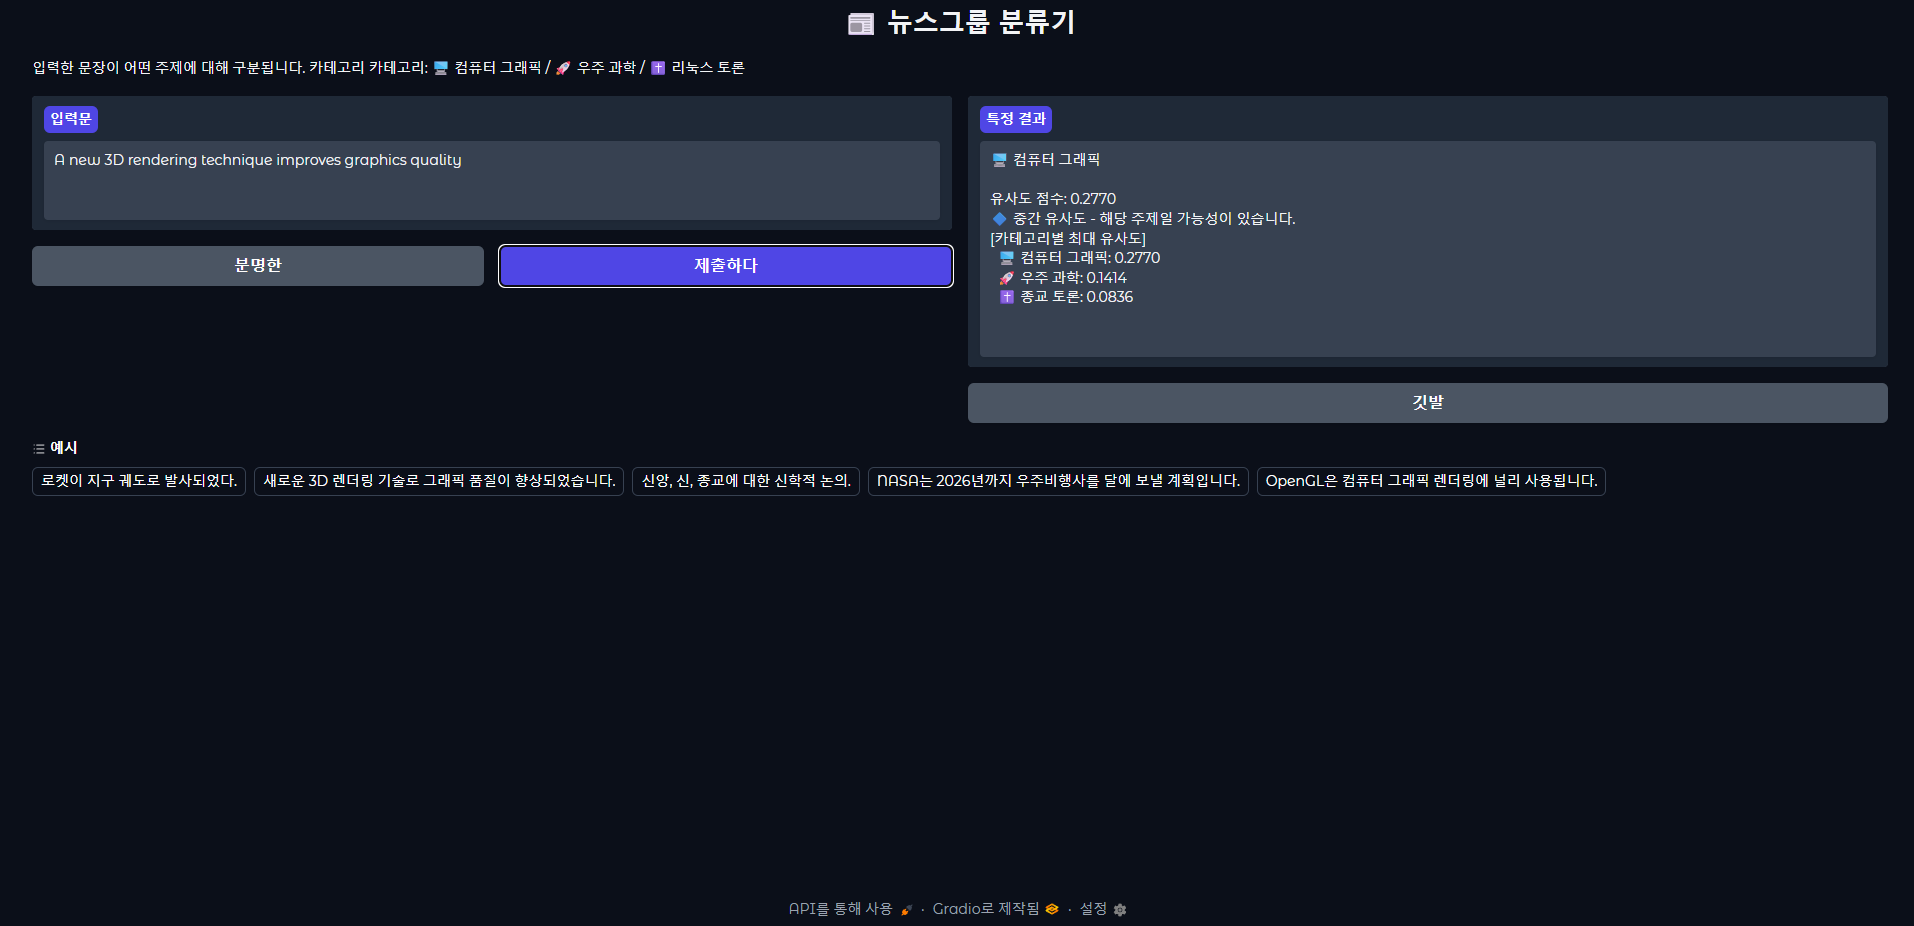

---
## 10. 결론 및 배운 점

### 핵심 학습 내용

**1. 텍스트의 수치화(Vectorization) 원리**

자연어 처리에서 컴퓨터가 텍스트를 이해하려면 먼저 숫자로 변환해야 한다는 기본 원리를 체험했다.  
CountVectorizer는 각 단어의 출현 빈도를 세어 벡터를 만드는 가장 직관적인 방법이며,  
이 과정에서 **어휘 사전(vocabulary)** 이 모델의 "인식 범위"를 결정한다는 점을 직접 확인했다.

**2. 코사인 유사도의 동작 방식과 한계**

코사인 유사도는 벡터의 크기(문서 길이)가 아닌 **방향(단어 구성 비율)** 으로 유사성을 판단하기 때문에,  
길이가 다른 문서 간에도 공정한 비교가 가능하다는 장점이 있다.  
반면, 학습 데이터에 없는 단어는 아예 벡터에 반영되지 않아 유사도가 0이 되는  
**OOV(Out-Of-Vocabulary)** 문제를 직접 경험할 수 있었다.

**3. 데이터 양의 중요성**

샘플 20개와 100개의 결과를 비교하면서, NLP 모델의 성능은 알고리즘뿐 아니라  
**학습 데이터의 양과 다양성**에 크게 좌우된다는 점을 체감했다.  
실무에서 데이터 수집과 정제가 왜 중요한지를 이해하는 계기가 되었다.

**4. 벡터화 기법에 따른 성능 차이**

동일한 데이터라도 CountVectorizer, TfidfVectorizer, n-gram 설정에 따라  
분류 결과가 달라진다는 것을 실험으로 확인했다.  
특히 TF-IDF는 단순 빈도의 한계를 보완하여 카테고리별 핵심 단어를 더 잘 구별해 주며,  
n-gram은 문맥 정보를 추가할 수 있지만 데이터가 적을 때는 오히려 희소성 문제를 악화시킬 수 있음을 배웠다.

**5. 전처리의 중요성**

뉴스그룹 데이터에서 헤더, 푸터, 인용구를 제거하지 않으면 이메일 주소나 서명 같은  
불필요한 정보가 벡터에 포함되어 분류 정확도를 떨어뜨린다.  
또한 불용어(stop words) 제거를 통해 "the", "is" 같은 의미 없는 단어를 걸러내는 것이  
벡터의 품질을 높이는 데 큰 역할을 한다는 것을 확인했다.

### 향후 발전 방향

본 과제에서 사용한 Bag-of-Words 기반 접근법은 NLP의 기초이며, 다음과 같은 한계가 있다:

- **단어 순서 무시**: "dog bites man"과 "man bites dog"이 동일한 벡터로 표현됨
- **의미적 유사성 미반영**: "car"와 "automobile"이 완전히 다른 단어로 취급됨
- **OOV 문제**: 학습 데이터에 없는 단어는 처리 불가

이러한 한계는 **Word2Vec**, **FastText** 같은 단어 임베딩 기법이나,  
**BERT**, **GPT** 같은 사전 학습된 언어 모델을 활용하면 해결할 수 있다.  
이번 과제를 통해 기초적인 텍스트 수치화와 유사도 기반 분류의 원리를 이해했으므로,  
향후 이러한 고급 기법을 학습할 때 더 깊은 이해가 가능할 것으로 기대한다.